# Copy Correction Procedure

Simplify the copy correction procedure and verify the normalization is properly handled.

**Motivation:** Previous copy correction procedure is incorrect, in that the goal is to make each timepoint equivalent. 

**Procedure:**
1. Normalize all samples by length distribution (and thus equal total number of reads)
2. For each 10k window, determine the replication time and copy number profile (computed from CLOCCS).
3. Reduce the count by half for replicated regions.
4. Question: Should we renormalize the samples? First intuition is, because the entirety of G2/M will now have half the number of reads compared to G1.


In [7]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1127]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

chrom = 6
span = (20000, 30000)
genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, span, log=False)


In [1122]:
from src.copy_correction_reanalysis import CopyCorrector

corrector = CopyCorrector()

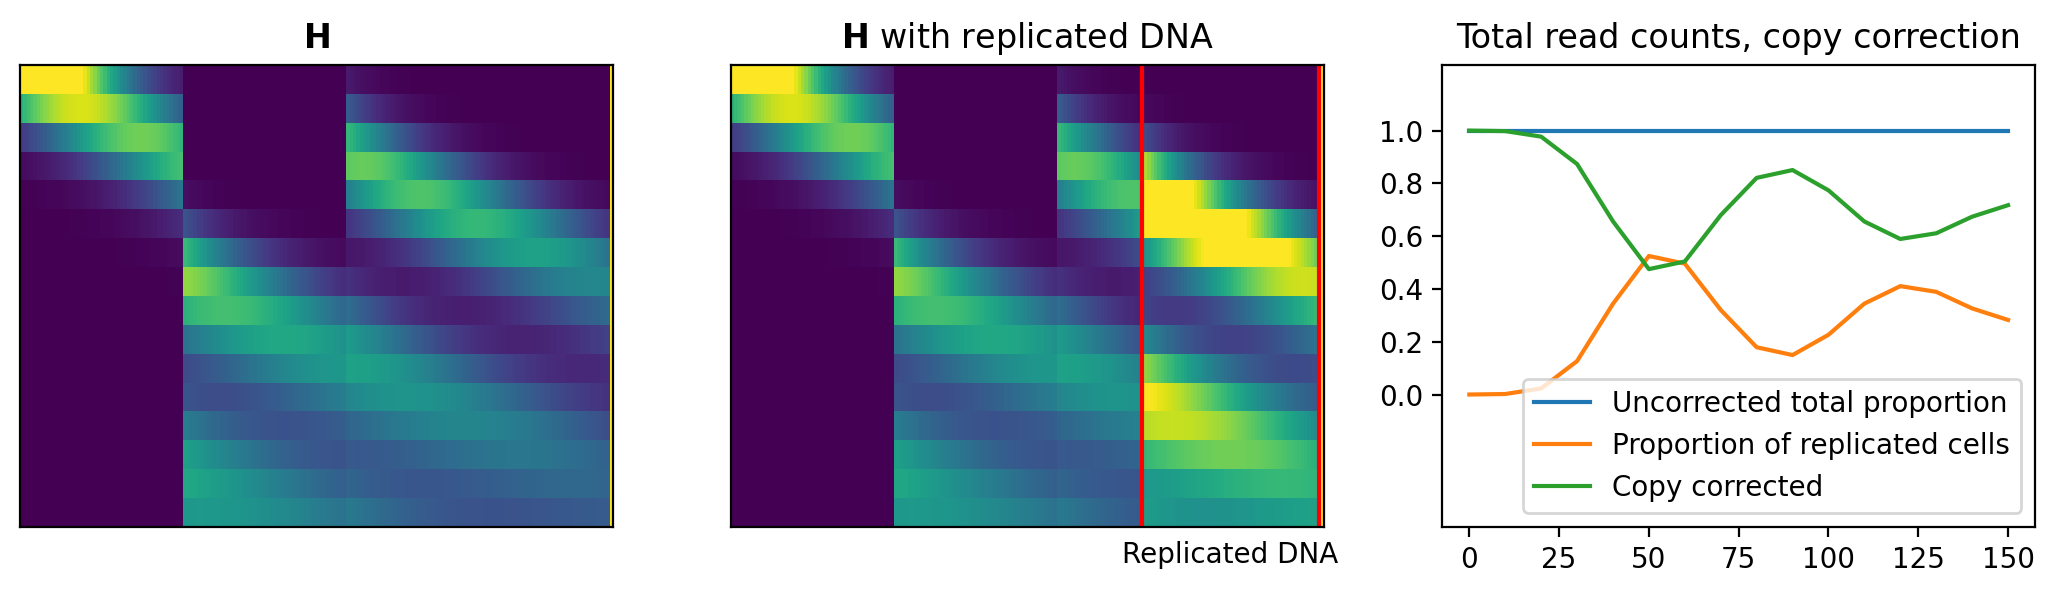

In [1123]:
corrector.plot_correction_H()

(0.0, 20000.0)

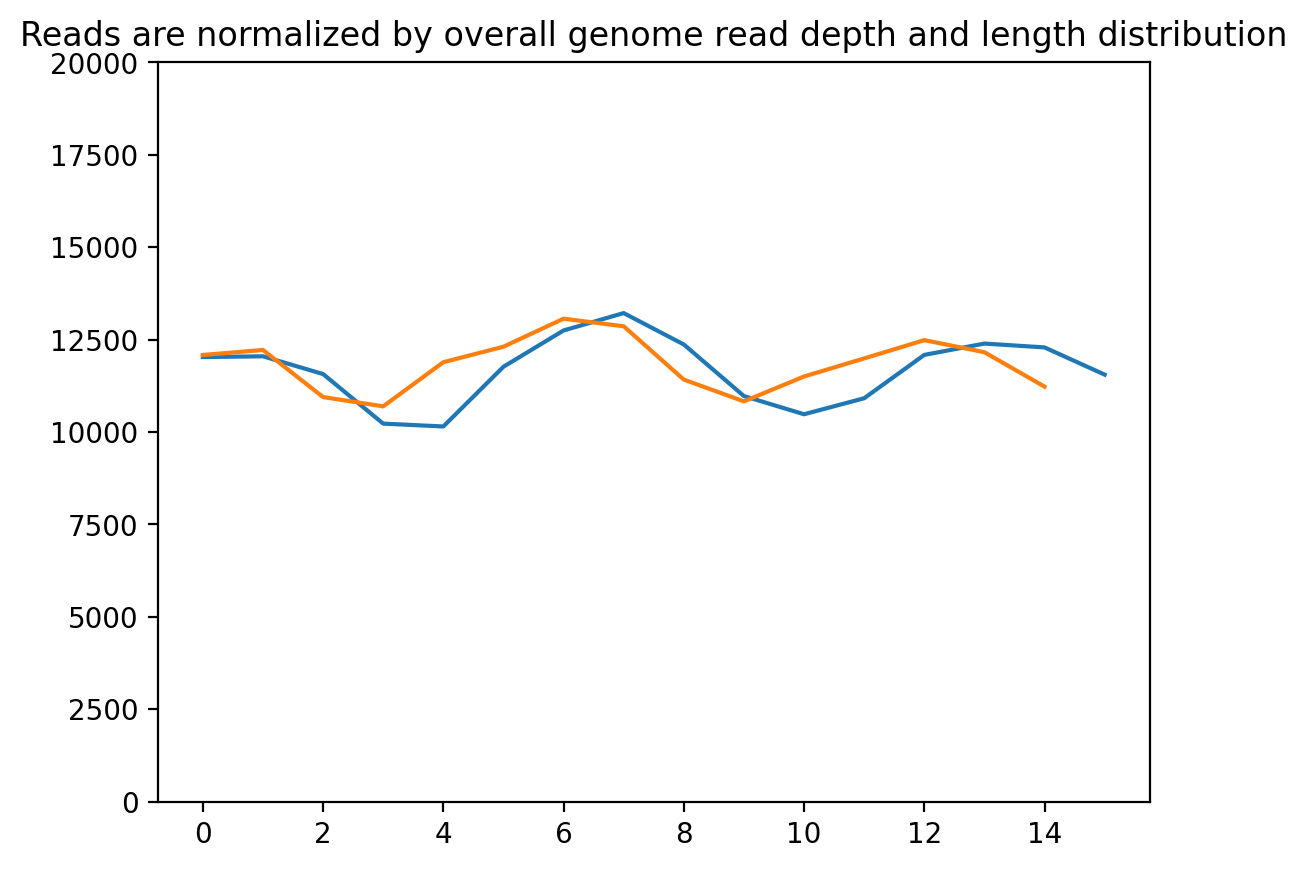

In [1128]:
plt.plot(genome_deconvolution.combined_model.chrom1_model.uncorrected_G.sum(axis=1))
plt.plot(genome_deconvolution.combined_model.chrom2_model.uncorrected_G.sum(axis=1))

plt.title("Reads are normalized by overall genome read depth and length distribution")
plt.ylim(0, 20000)


In [1129]:
replication_idx = chrom_replication_profile.loc[chrom].loc[span[0]].replication_index

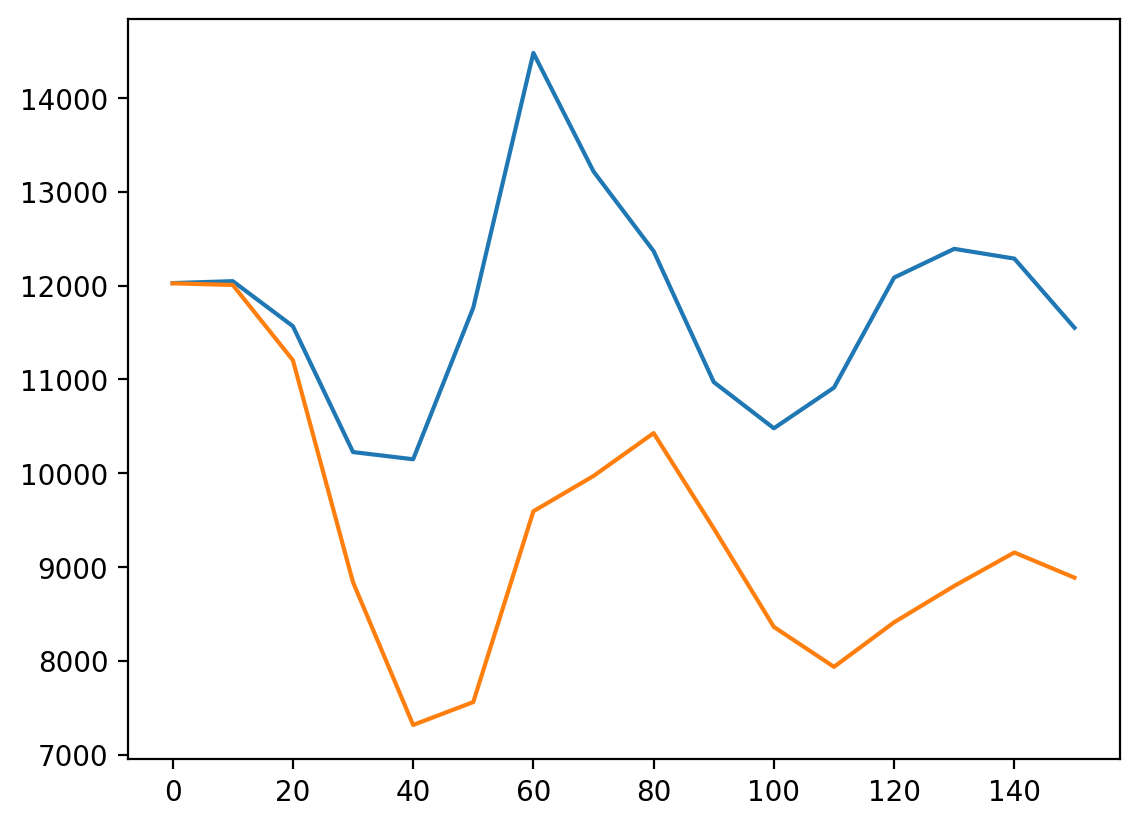

In [1131]:
def perform_correction(uncorrected_reads, proportion_of_replicated_DNA):
    corrected_reads = uncorrected_reads - uncorrected_reads * proportion_of_replicated_DNA
    correction_scalar = corrected_reads / uncorrected_reads
    return uncorrected_reads, corrected_reads, correction_scalar

plt.plot(timepoints, uncorrected_reads)
plt.plot(timepoints, uncorrected_reads*correction_scalar)


In [1072]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis
from src.timer import Timer
from src.global_config import GlobalConstants
from src.global_config import GlobalConstants

def create_chrom_lengths_dist_df(exact_1, tps, chrom, should_sum=True):
    """Create a dataframe with the length distributions for a replicate and chromosome
    """
    if should_sum:
        exact_1 = exact_1.sum(axis=2).T
    
    rep1_current_lengths_distr = pd.DataFrame(exact_1, 
        columns=tps)
    rep1_current_lengths_distr['chrom'] = chrom
    rep1_current_lengths_distr.index.name = 'length'
    rep1_current_lengths_distr = rep1_current_lengths_distr.reset_index()
    rep1_current_lengths_distr = rep1_current_lengths_distr.set_index(['chrom', 'length'])
    return rep1_current_lengths_distr

replicate1_10k_normalized_sums = pd.DataFrame(columns=GlobalConstants.CHROM_WT1_TIMEPOINTS,
    index=all_10k_windows[[]].index)
replicate2_10k_normalized_sums = pd.DataFrame(columns=GlobalConstants.CHROM_WT2_TIMEPOINTS,
    index=all_10k_windows[[]].index)

# The length distributions for each chromosome and each timepoint
replicate1_10k_length_sums = pd.DataFrame()
replicate2_10k_length_sums = pd.DataFrame()

all_10k_windows = pd.read_csv('data/reference_data/sacCer3_genome_10k_windows.csv')\
    .set_index(['chr', 'start'])

genome_deconvolution = GenomeDeconvolution(save_dir=None)
timer = Timer()

tps1 = GlobalConstants.CHROM_WT1_TIMEPOINTS
tps2 = GlobalConstants.CHROM_WT2_TIMEPOINTS
    
for chrom in range(1, 17):
    print(f"Chromosome {chrom}...")
    
    # Create the baseline length distributions for the chromosome
    # Containing the cumulative counts for each length and timepoint for
    # the chromosome

    zeros1 = np.zeros((251, len(tps1)))
    zeros2 = np.zeros((251, len(tps2)))

    rep1_lengths_df = create_chrom_lengths_dist_df(zeros1, 
        tps1, chrom, should_sum=False)
    rep2_lengths_df = create_chrom_lengths_dist_df(zeros2,
        tps2, chrom, should_sum=False)

    for start, row in all_10k_windows.loc[chrom].iterrows():
        
        print(start, end=',')
        end = row.end
        span = (start, end)

        genome_deconvolution.load_chrom_span(chrom, span, log=False, downsample=False)    
        normalized_1 = genome_deconvolution.combined_model.chrom1_model.normalized_bins
        normalized_2 = genome_deconvolution.combined_model.chrom2_model.normalized_bins
        exact_1 = genome_deconvolution.combined_model.chrom1_model.exact_bins
        exact_2 = genome_deconvolution.combined_model.chrom2_model.exact_bins

        rep1_summed_uncorrected_normalized_bins = normalized_1.sum(axis=1).sum(axis=1)
        rep2_summed_uncorrected_normalized_bins = normalized_2.sum(axis=1).sum(axis=1)
        rep1_summed_exact_bins = exact_1.sum(axis=1).sum(axis=1)
        rep2_summed_exact_bins = exact_2.sum(axis=1).sum(axis=1)

        replicate1_10k_normalized_sums.loc[chrom].loc[start] = \
            rep1_summed_uncorrected_normalized_bins
        replicate2_10k_normalized_sums.loc[chrom].loc[start] = \
            rep2_summed_uncorrected_normalized_bins
        
        rep1_current_lengths_distr = create_lengths_dist_df(exact_1, 
            GlobalConstants.CHROM_WT1_TIMEPOINTS, chrom)
        rep2_current_lengths_distr = create_lengths_dist_df(exact_2, 
            GlobalConstants.CHROM_WT2_TIMEPOINTS, chrom)

        rep1_lengths_df += rep1_current_lengths_distr
        rep2_lengths_df += rep2_current_lengths_distr

    replicate1_10k_length_sums = pd.concat([replicate1_10k_length_sums, 
        rep1_lengths_df])
    replicate2_10k_length_sums = pd.concat([replicate2_10k_length_sums, 
        rep2_lengths_df])

    print("")
    timer.print_time()


Chromosome 1...
0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000,130000,140000,150000,160000,170000,180000,190000,200000,210000,220000,230000,
00:00:22.885
Chromosome 2...
0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000,130000,140000,150000,160000,170000,180000,190000,200000,210000,220000,230000,240000,250000,260000,270000,280000,290000,300000,310000,320000,330000,340000,350000,360000,370000,380000,390000,400000,410000,420000,430000,440000,450000,460000,470000,480000,490000,500000,510000,520000,530000,540000,550000,560000,570000,580000,590000,600000,610000,620000,630000,640000,650000,660000,670000,680000,690000,700000,710000,720000,730000,740000,750000,760000,770000,780000,790000,800000,810000,
00:01:52.509
Chromosome 3...
0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000,130000,140000,150000,160000,170000,180000,190000,200000,210000,220000,230000,240000,250000,260000,270000,280000,290000,300000,310000,

0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000,130000,140000,150000,160000,170000,180000,190000,200000,210000,220000,230000,240000,250000,260000,270000,280000,290000,300000,310000,320000,330000,340000,350000,360000,370000,380000,390000,400000,410000,420000,430000,440000,450000,460000,470000,480000,490000,500000,510000,520000,530000,540000,550000,560000,570000,580000,590000,600000,610000,620000,630000,640000,650000,660000,670000,680000,690000,700000,710000,720000,730000,740000,750000,760000,770000,780000,790000,800000,810000,820000,830000,840000,850000,860000,870000,880000,890000,900000,910000,920000,930000,940000,
00:21:48.587


In [518]:
def plot_rep_tp_counts(rep1_tp_counts, rep2_tp_counts):
    from src.chromatin_metrics import compute_scaling_matrix, \
    convert_scaling_matrix_to_len_bins, plot_len_counts
    
    plt.figure(figsize=(23, 7))
    plt.subplots_adjust(top=0.8)

    plt.subplot(1, 2, 1)
    plot_len_counts(rep1_tp_counts)
    plt.title("Replicate 1", fontsize=23, pad=15)

    plt.subplot(1, 2, 2)
    plot_len_counts(rep2_tp_counts)
    plt.title("Replicate 2", fontsize=23, pad=15)

    plt.suptitle("Fragment length distribution", fontsize=32)


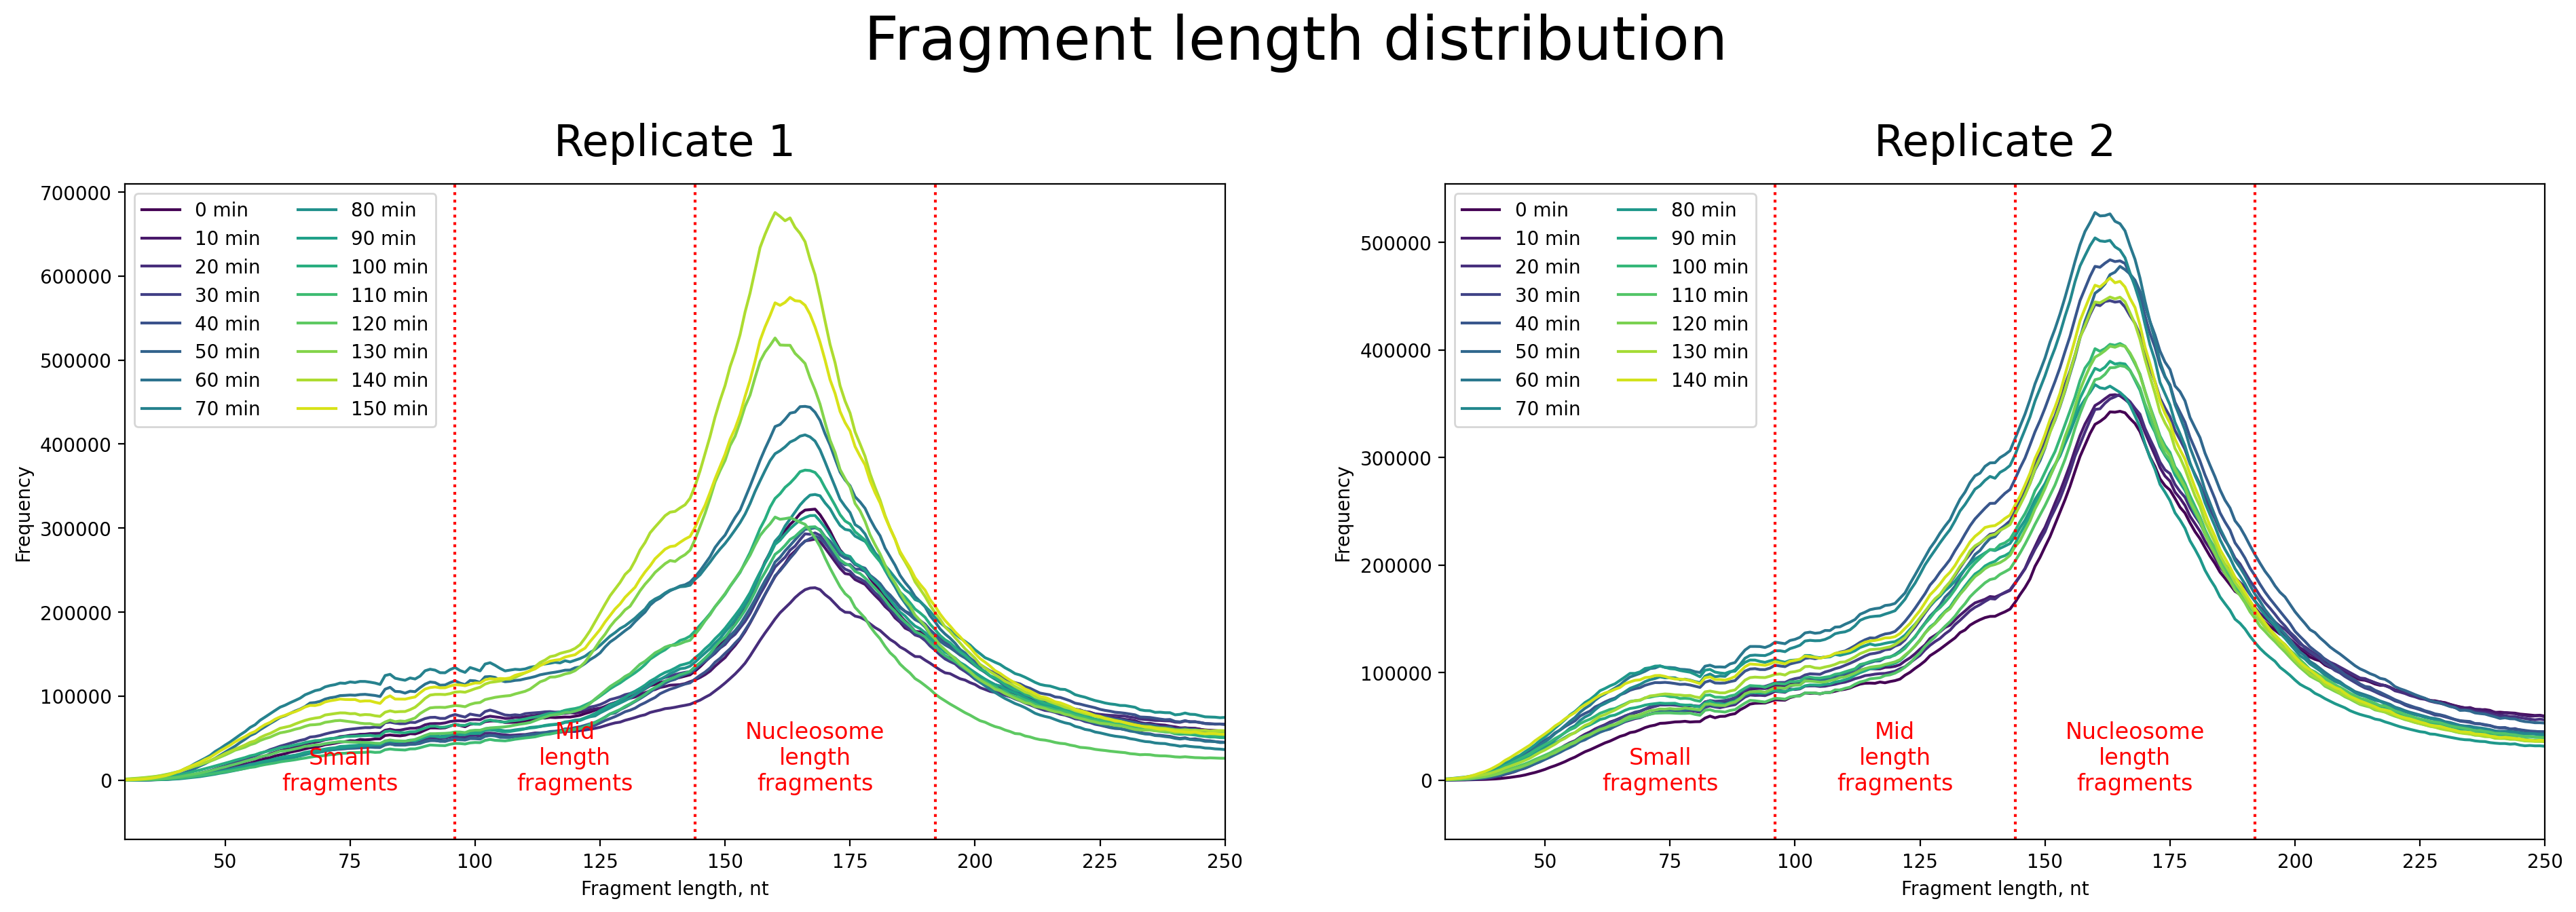

In [519]:
plot_rep_tp_counts(rep1_len_sums_per_time, rep2_len_sums_per_time)

In [540]:
# Compute the minimum length for each timepoint for both replicates
rep1_len_sums_per_time = replicate1_10k_length_sums.reset_index()\
    .groupby('length').sum()[tps1]
min_lens_per_time1 = rep1_len_sums_per_time.min(axis=1)
rep2_len_sums_per_time = replicate2_10k_length_sums.reset_index()\
    .groupby('length').sum()[tps2]
min_lens_per_time2 = rep2_len_sums_per_time.min(axis=1)

# Then combine replicate 1 and 2 and take the minimum per length
# to get an overall target distribution
target_len_dist = np.stack([min_lens_per_time1, min_lens_per_time2]).min(axis=0)

In [549]:
# Compute the scaling matrix for each replicate
scaling_factor1 = (target_len_dist.reshape((-1, 1))+1) / (rep1_len_sums_per_time+1)
scaling_factor2 = (target_len_dist.reshape((-1, 1))+1) / (rep2_len_sums_per_time+1)

In [712]:

def scale_target_length_distributions(replicate1_10k_length_sums, scaling_factor1):
    """Scale the target length distributions to the target distribution
    using the given scaling factor matrix.
    
    Note:
    Assumes length sums are broken by chromosomes"""
    testing_target_chrom_dist = replicate1_10k_length_sums.copy()

    for chrom in range(1, 17):
        for tp in replicate1_10k_length_sums.columns:
            chrom_tp_sum = replicate1_10k_length_sums.loc[chrom][tp]
            target_dist = chrom_tp_sum * scaling_factor1[tp]
            for frag_len in testing_target_chrom_dist.loc[chrom].index:
                testing_target_chrom_dist.loc[chrom].loc[frag_len][tp] = \
                    target_dist[frag_len].copy()

    return testing_target_chrom_dist


In [713]:
test_target_sum1 = scale_target_length_distributions(replicate1_10k_length_sums, 
    scaling_factor1)

In [714]:
test_target_sum2 = scale_target_length_distributions(replicate2_10k_length_sums, 
    scaling_factor2)

0

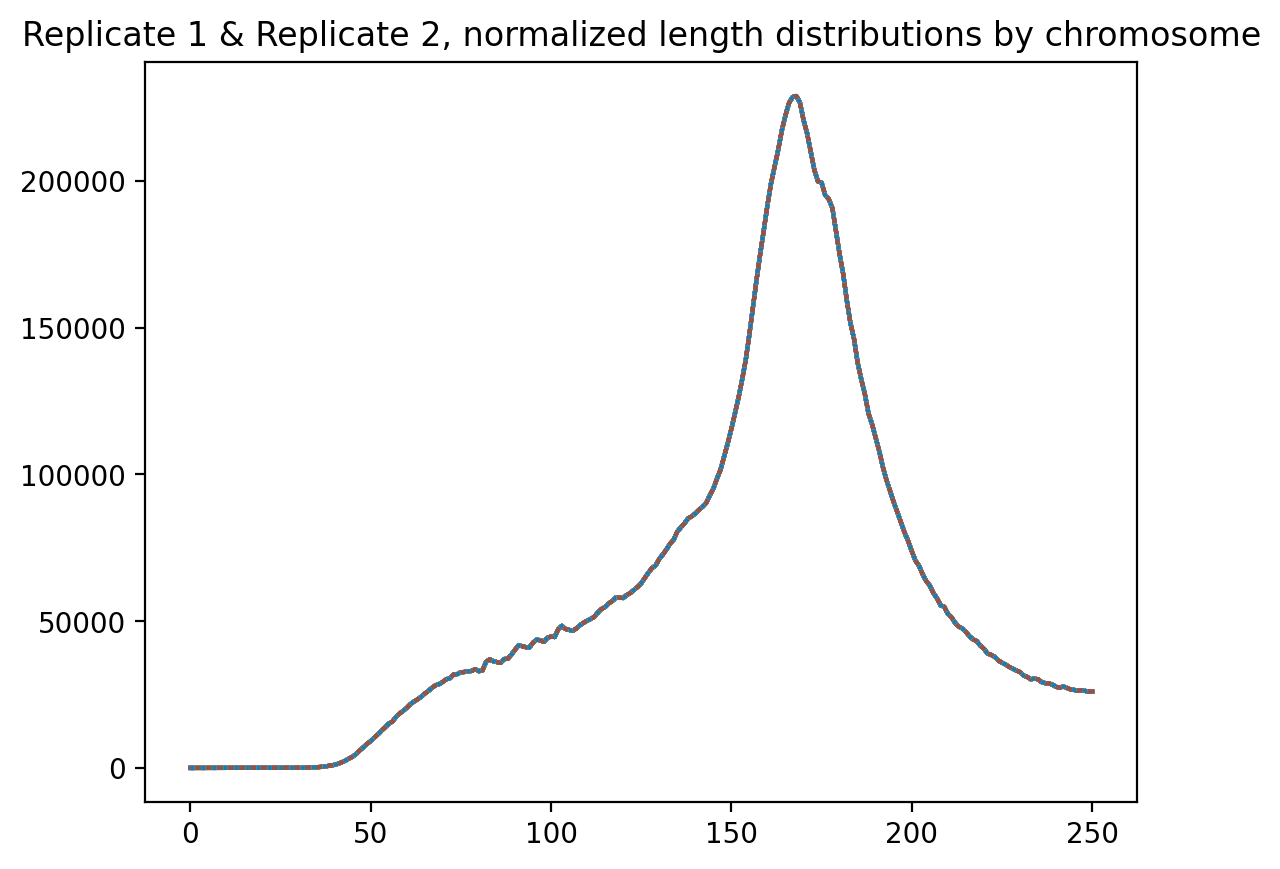

In [731]:

plt.plot(test_target_sum1.groupby('length').sum(), label="Replicate 1", ls='solid')
plt.plot(test_target_sum2.groupby('length').sum(), label="Replicate 2", ls='dotted')
plt.title("Replicate 1 & Replicate 2, normalized length distributions by chromosome")
0

In [1073]:
all_10k_windows = pd.read_csv('data/reference_data/sacCer3_genome_10k_windows.csv')\
    .set_index(['chr', 'start'])

genome_deconvolution = GenomeDeconvolution(save_dir=None)
timer = Timer()

tps1 = GlobalConstants.CHROM_WT1_TIMEPOINTS
tps2 = GlobalConstants.CHROM_WT2_TIMEPOINTS

rep1_all_exact_counts = pd.DataFrame()
rep2_all_exact_counts = pd.DataFrame()

rep1_all_normalized_counts = pd.DataFrame()
rep2_all_normalized_counts = pd.DataFrame()

for chrom in range(1, 17):
    print(f"Chromosome {chrom}...")

    def create_chrom_counts_df(tps, replicate):
        chrom1_counts = pd.DataFrame( np.zeros((len(tps), 251)).T, columns=tps)
        chrom1_counts.index.name = 'length'
        chrom1_counts = chrom1_counts.reset_index()
        chrom1_counts['chrom'] = chrom
        chrom1_counts['replicate'] = replicate
        chrom1_counts = chrom1_counts.set_index(['replicate', 'chrom', 'length'])
        return chrom1_counts
    
    chrom1_counts = create_chrom_counts_df(tps1, 1)
    chrom2_counts = create_chrom_counts_df(tps2, 2)
    
    normalized_chrom1_counts = create_chrom_counts_df(tps1, 1)
    normalized_chrom2_counts = create_chrom_counts_df(tps2, 2)

    for start, row in all_10k_windows.loc[chrom].iterrows():
        
        print(start, end=',')
        end = row.end
        span = (start, end)

        genome_deconvolution.load_chrom_span(chrom, span, log=False, downsample=False)
        exact_1 = genome_deconvolution.combined_model.chrom1_model.exact_bins
        exact_2 = genome_deconvolution.combined_model.chrom2_model.exact_bins
        normalized_1 = genome_deconvolution.combined_model.chrom1_model.normalized_bins
        normalized_2 = genome_deconvolution.combined_model.chrom2_model.normalized_bins
        
        chrom1_counts.loc[1].loc[chrom].loc[:] += exact_1.sum(axis=2).T
        chrom2_counts.loc[2].loc[chrom].loc[:] += exact_2.sum(axis=2).T
        
        normalized_chrom1_counts.loc[1].loc[chrom].loc[:] += normalized_1.sum(axis=2).T
        normalized_chrom2_counts.loc[2].loc[chrom].loc[:] += normalized_2.sum(axis=2).T

    rep1_all_exact_counts = pd.concat([rep1_all_exact_counts, chrom1_counts])
    rep2_all_exact_counts = pd.concat([rep2_all_exact_counts, chrom2_counts])
    
    rep1_all_normalized_counts = pd.concat([rep1_all_normalized_counts, 
                                            normalized_chrom1_counts])
    rep2_all_normalized_counts = pd.concat([rep2_all_normalized_counts, 
                                            normalized_chrom2_counts])
    
    print("")
    timer.print_time()


Chromosome 1...
0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000,130000,140000,150000,160000,170000,180000,190000,200000,210000,220000,230000,
00:00:19.909
Chromosome 2...
0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000,130000,140000,150000,160000,170000,180000,190000,200000,210000,220000,230000,240000,250000,260000,270000,280000,290000,300000,310000,320000,330000,340000,350000,360000,370000,380000,390000,400000,410000,420000,430000,440000,450000,460000,470000,480000,490000,500000,510000,520000,530000,540000,550000,560000,570000,580000,590000,600000,610000,620000,630000,640000,650000,660000,670000,680000,690000,700000,710000,720000,730000,740000,750000,760000,770000,780000,790000,800000,810000,
00:01:43.478
Chromosome 3...
0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000,130000,140000,150000,160000,170000,180000,190000,200000,210000,220000,230000,240000,250000,260000,270000,280000,290000,300000,310000,

0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000,130000,140000,150000,160000,170000,180000,190000,200000,210000,220000,230000,240000,250000,260000,270000,280000,290000,300000,310000,320000,330000,340000,350000,360000,370000,380000,390000,400000,410000,420000,430000,440000,450000,460000,470000,480000,490000,500000,510000,520000,530000,540000,550000,560000,570000,580000,590000,600000,610000,620000,630000,640000,650000,660000,670000,680000,690000,700000,710000,720000,730000,740000,750000,760000,770000,780000,790000,800000,810000,820000,830000,840000,850000,860000,870000,880000,890000,900000,910000,920000,930000,940000,
00:21:02.890


0

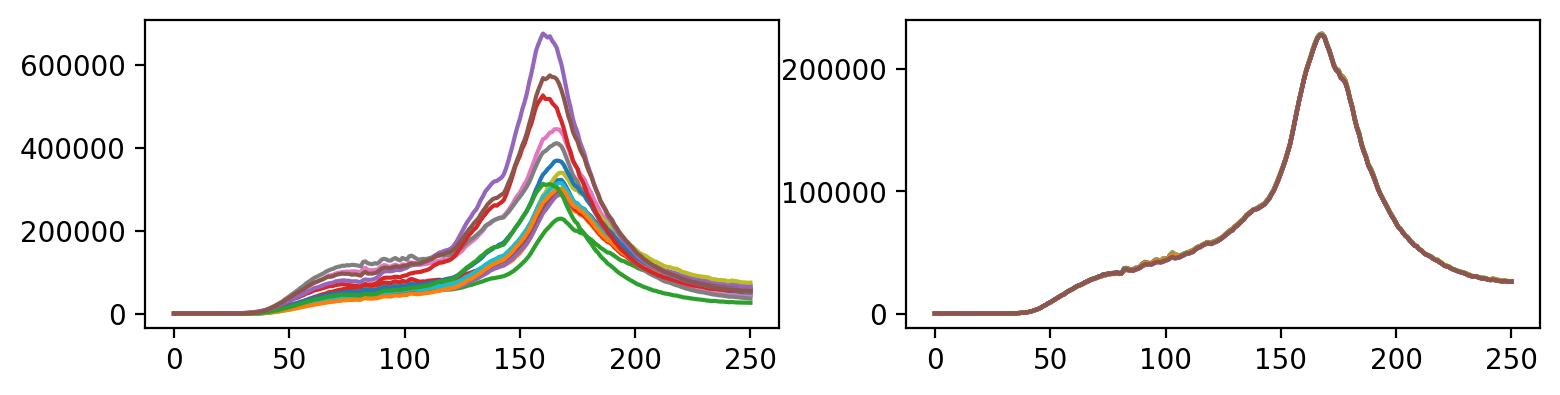

In [1071]:
plt.figure(figsize=(9, 2))
plt.subplot(1, 2, 1)
plt.plot(rep1_all_exact_counts.groupby('length').sum())

plt.subplot(1, 2, 2)
plt.plot(rep1_all_normalized_counts.groupby('length').sum())
0
